# 02 — Modelos clássicos (janelas IMDC)

Random Forest, XGBoost, LSTM, SARIMA e o ensemble RF+XGBoost, com hiperparâmetros idênticos ao estudo original. Executa e mostra R²/WIS e as figuras.

In [1]:
import matplotlib; matplotlib.use('Agg')
import os, sys, json, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from IPython.display import Image, display
AQUI = os.path.abspath('..')
sys.path.insert(0, AQUI)
FIG = os.path.join(AQUI, 'figuras'); RES = os.path.join(AQUI, 'resultados')
import imdc_splits as S
import modelos_imdc as M
ds=S.carregar_dataset(); CEN=S.montar_cenarios(ds); NF=len(ds['feature_names'])

In [2]:
modelos = [('RF',lambda:M.run_rf(CEN)),('XGBoost',lambda:M.run_xgb(CEN)),
           ('LSTM',lambda:M.run_lstm(CEN,NF)),('SARIMA',lambda:M.run_sarima(CEN)),
           ('EnsRFXGB',lambda:M.run_ensemble_rfxgb(CEN))]
tab=[]
for nome,fn in modelos:
    R=fn(); M.plot_imdc(R, f'{nome} — janelas IMDC', os.path.join(FIG,f'{nome}_pred_vs_obs.png'))
    for c,r in R.items(): tab.append([nome,c,round(r['R2'],3),round(r['WIS'],0)])
pd.DataFrame(tab, columns=['Modelo','Teste','R2','WIS'])

[SALVO] C:\Users\julia\OneDrive\Área de Trabalho\PIBIT\Experimentos\Relatorio_Final_IC\estudo_IMDC_janelas\figuras\RF_pred_vs_obs.png


[SALVO] C:\Users\julia\OneDrive\Área de Trabalho\PIBIT\Experimentos\Relatorio_Final_IC\estudo_IMDC_janelas\figuras\XGBoost_pred_vs_obs.png


[SALVO] C:\Users\julia\OneDrive\Área de Trabalho\PIBIT\Experimentos\Relatorio_Final_IC\estudo_IMDC_janelas\figuras\LSTM_pred_vs_obs.png


[SALVO] C:\Users\julia\OneDrive\Área de Trabalho\PIBIT\Experimentos\Relatorio_Final_IC\estudo_IMDC_janelas\figuras\SARIMA_pred_vs_obs.png


[SALVO] C:\Users\julia\OneDrive\Área de Trabalho\PIBIT\Experimentos\Relatorio_Final_IC\estudo_IMDC_janelas\figuras\EnsRFXGB_pred_vs_obs.png


,Modelo,Teste,R2,WIS
0,RF,T1,0.636,110.0
1,RF,T2,-0.057,4500.0
2,RF,T3,0.691,58.0
3,XGBoost,T1,0.599,102.0
4,XGBoost,T2,-0.035,4442.0
5,XGBoost,T3,0.637,59.0
6,LSTM,T1,-3.448,600.0
7,LSTM,T2,-0.408,5854.0
8,LSTM,T3,-19.795,813.0
9,SARIMA,T1,-1.583,179.0


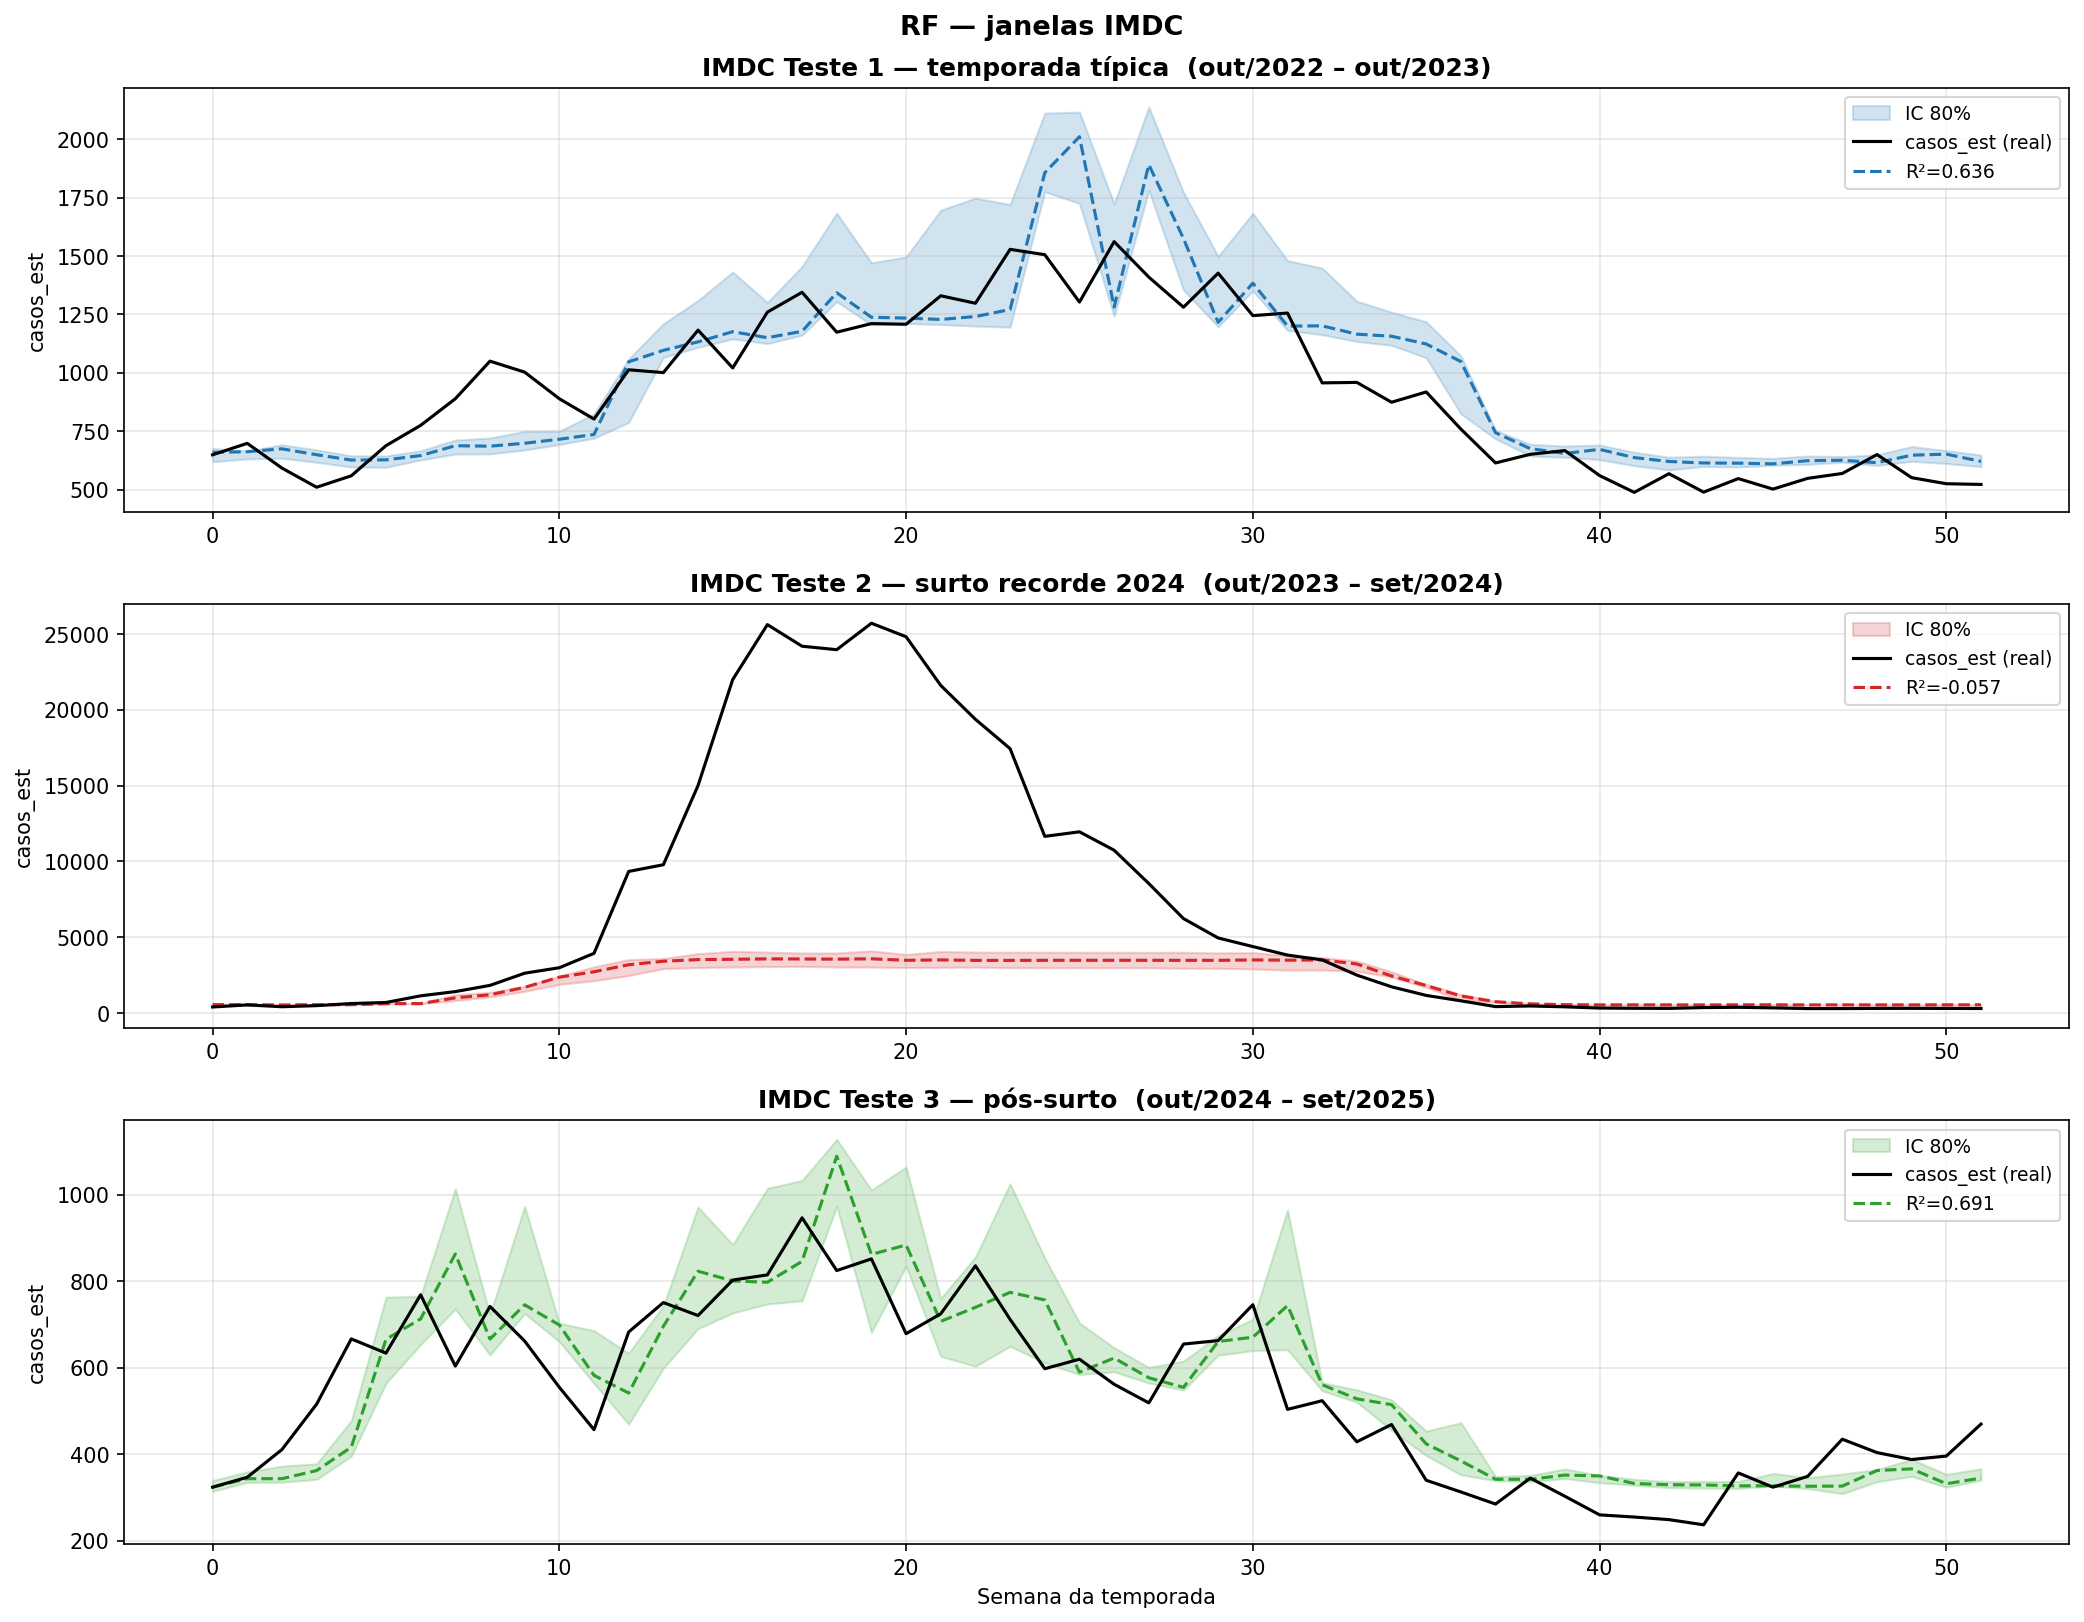

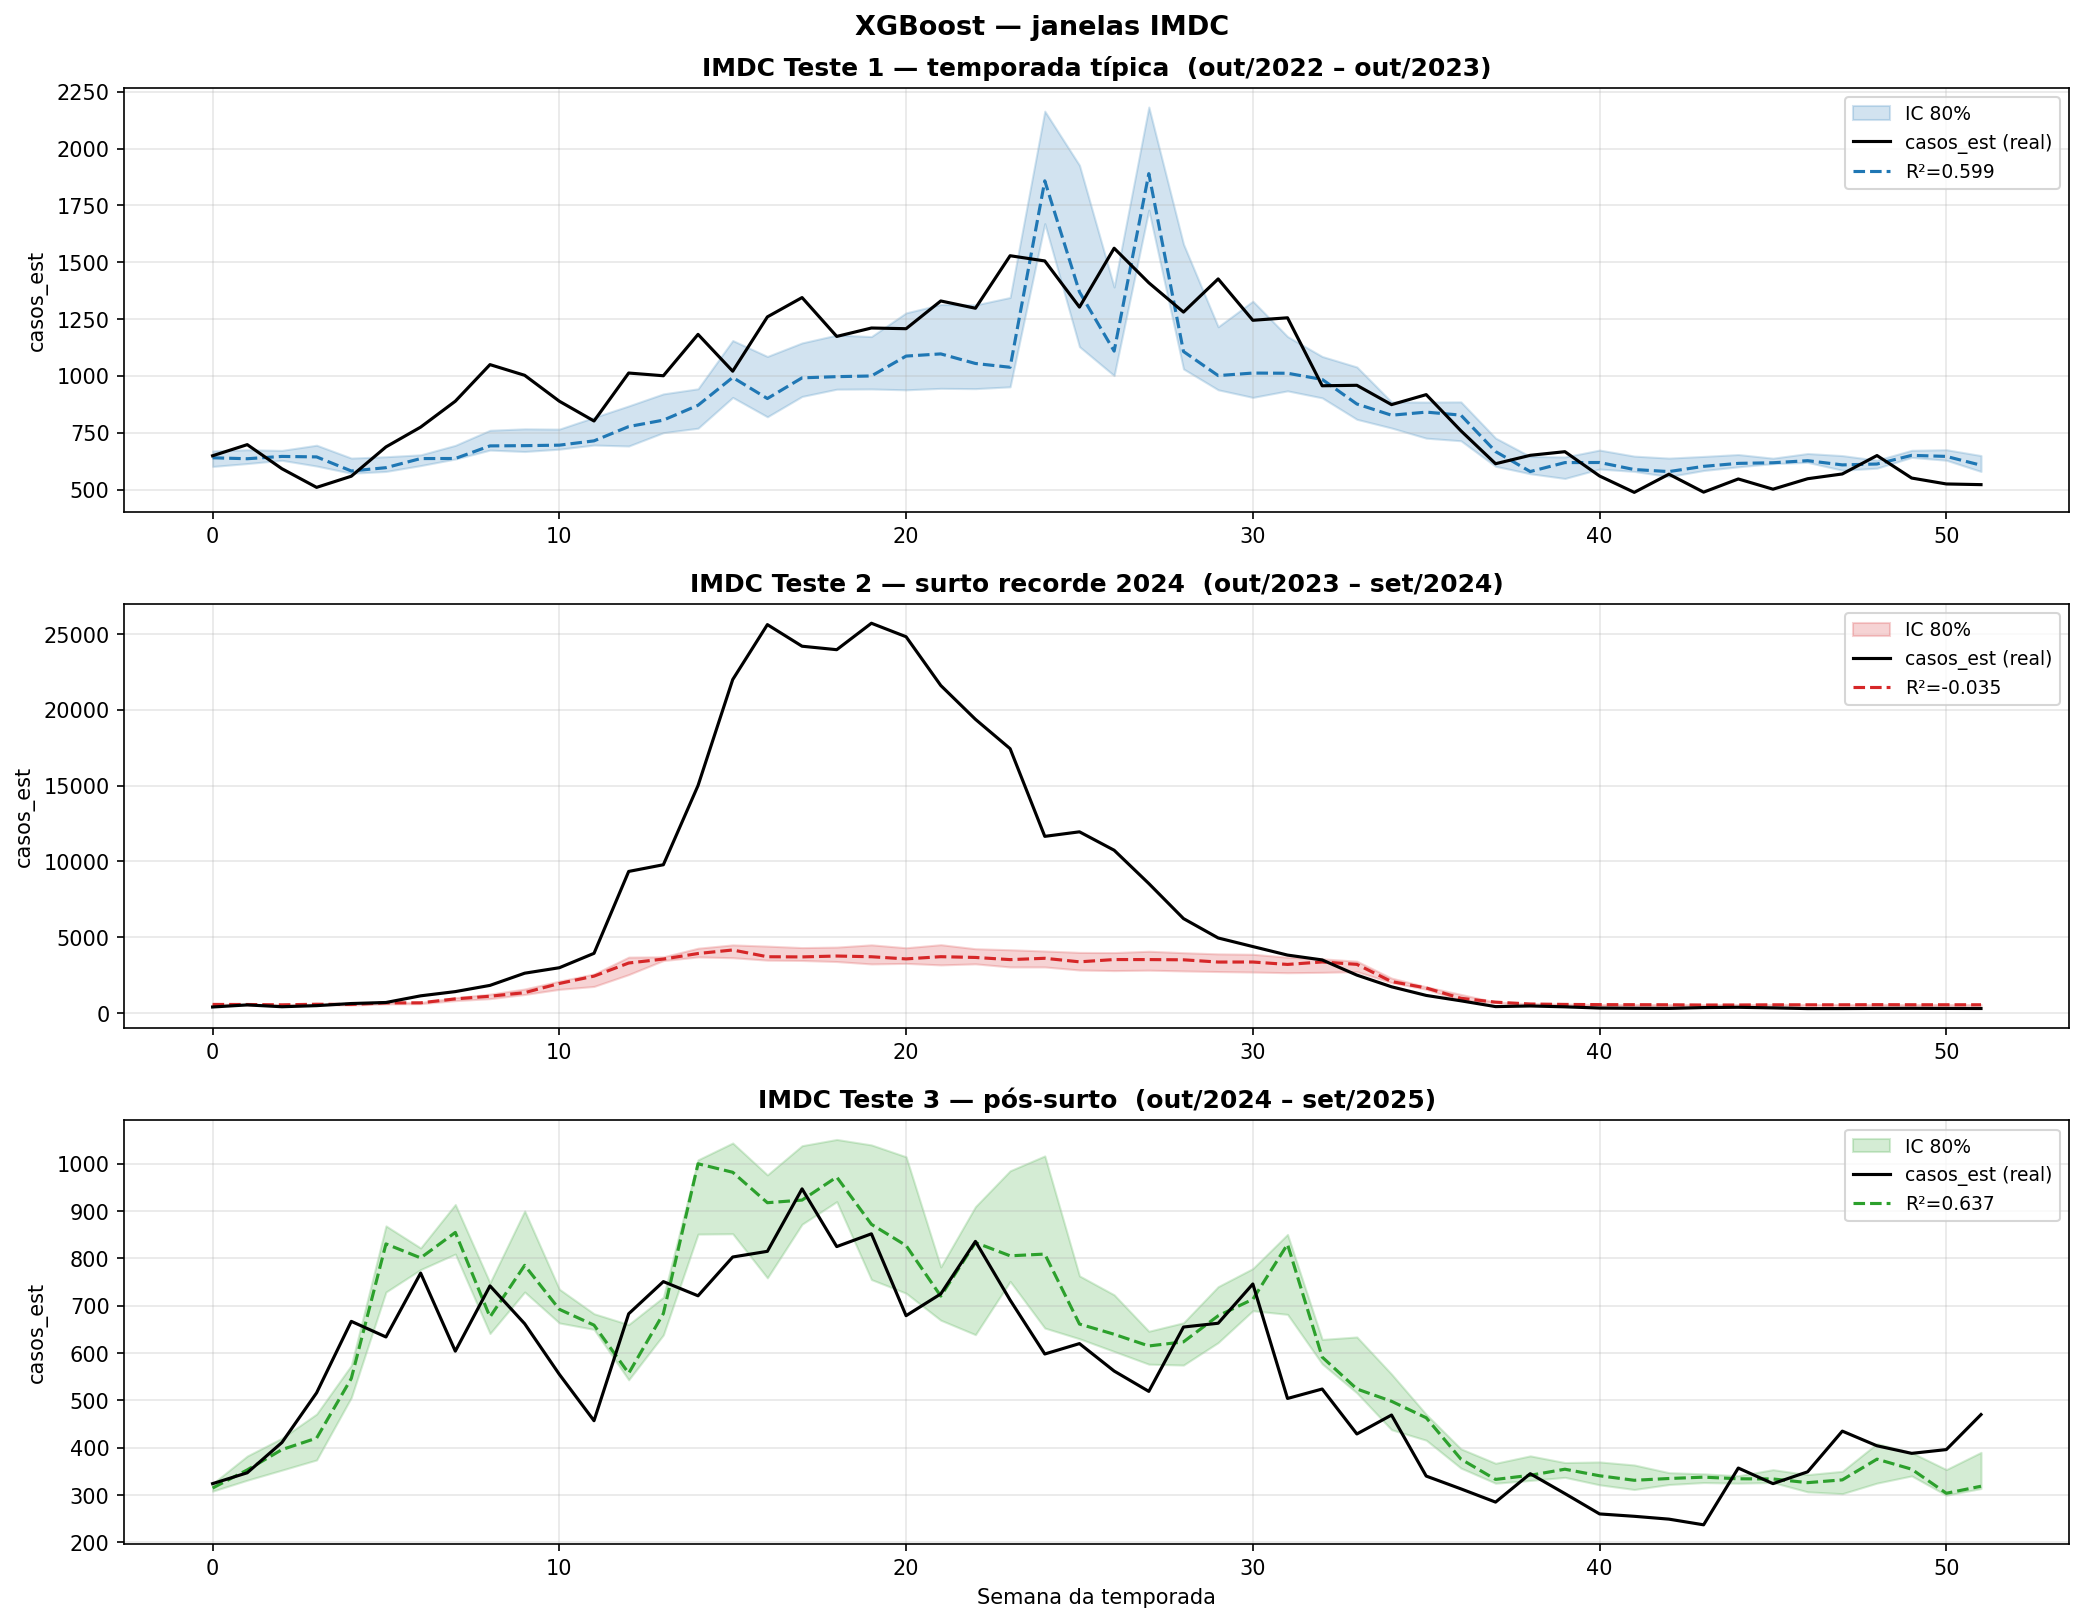

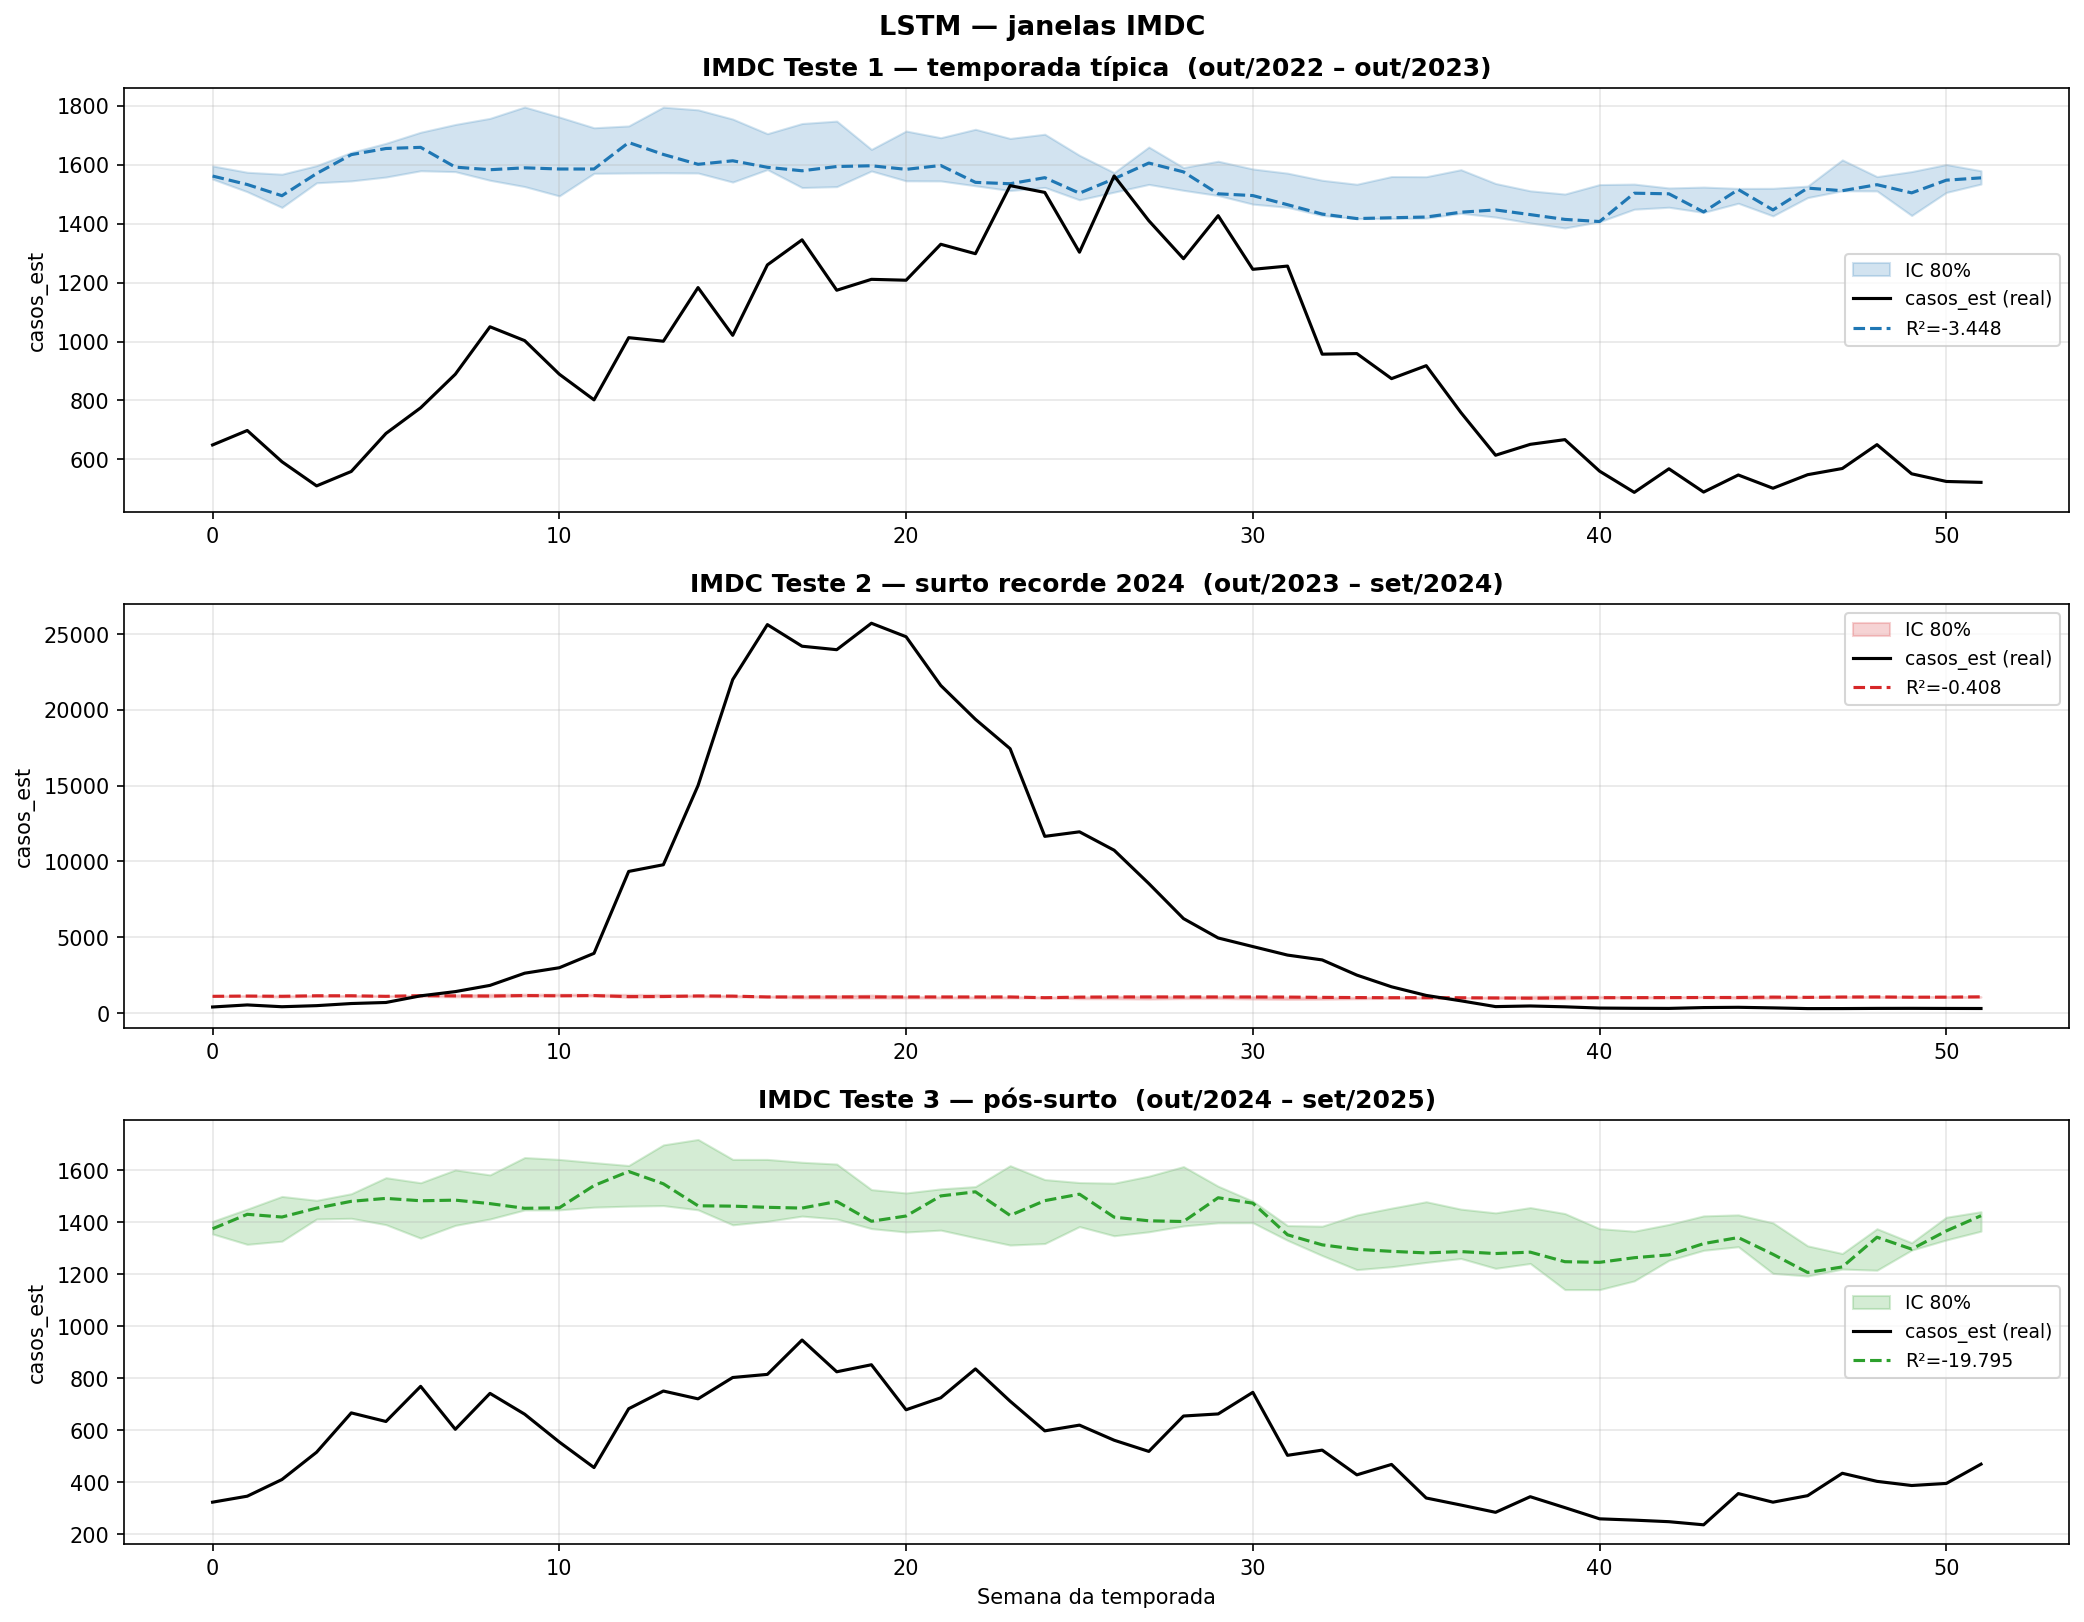

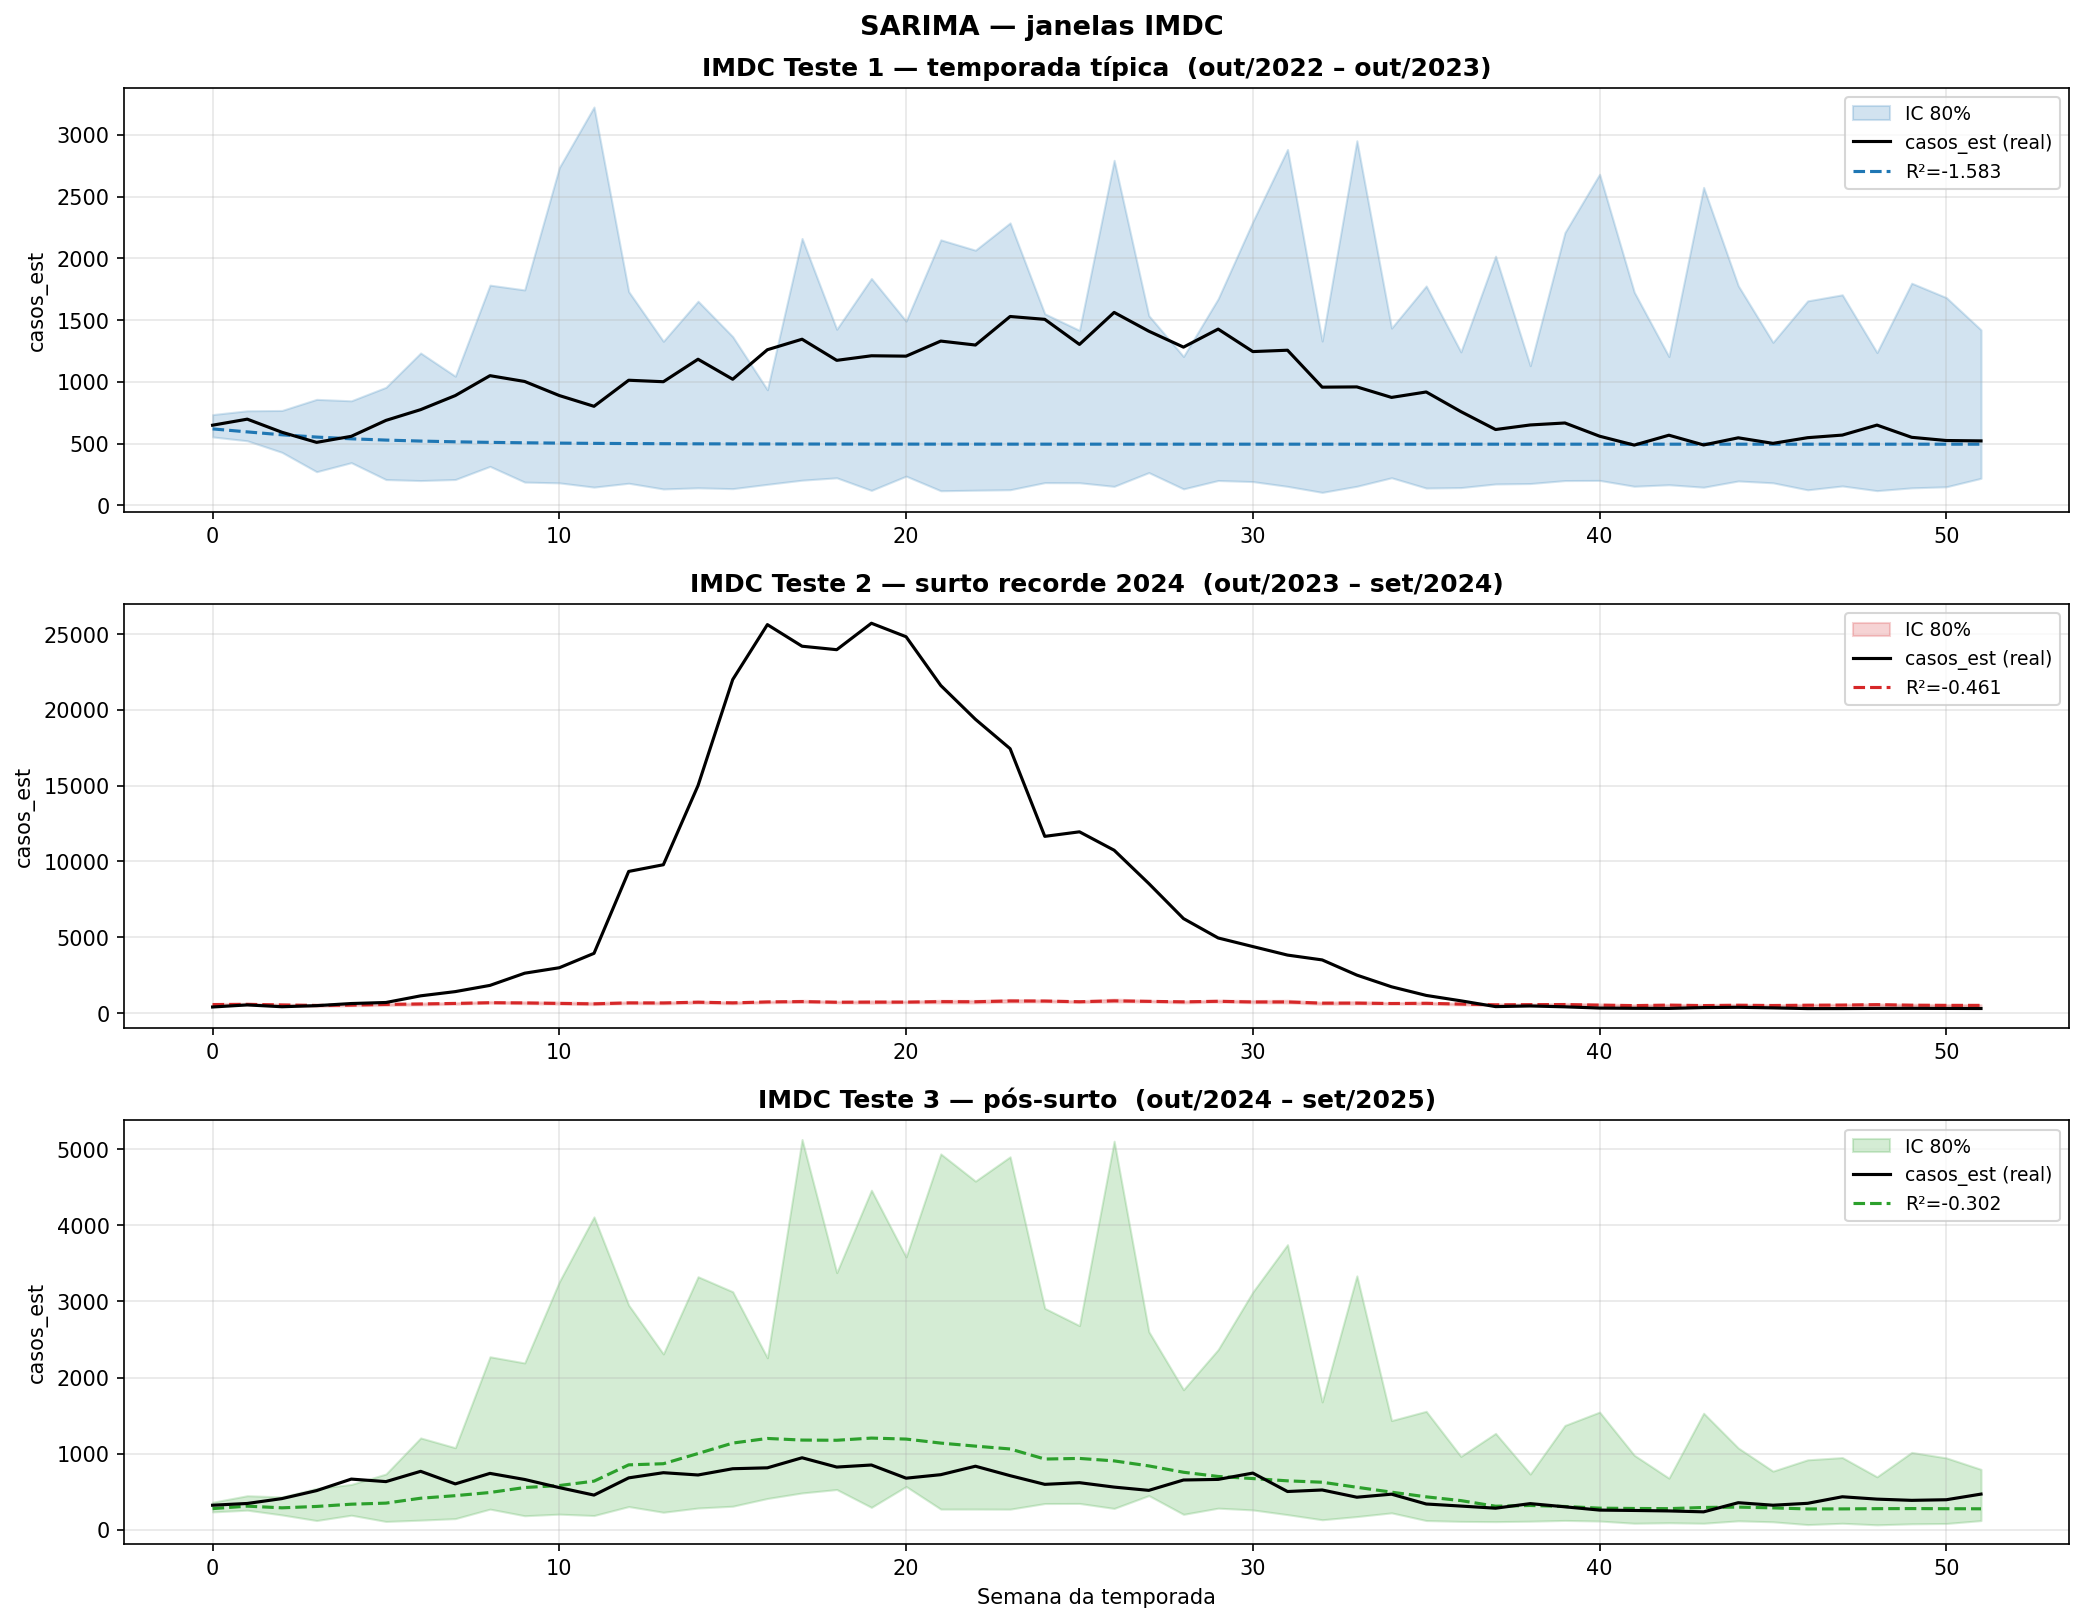

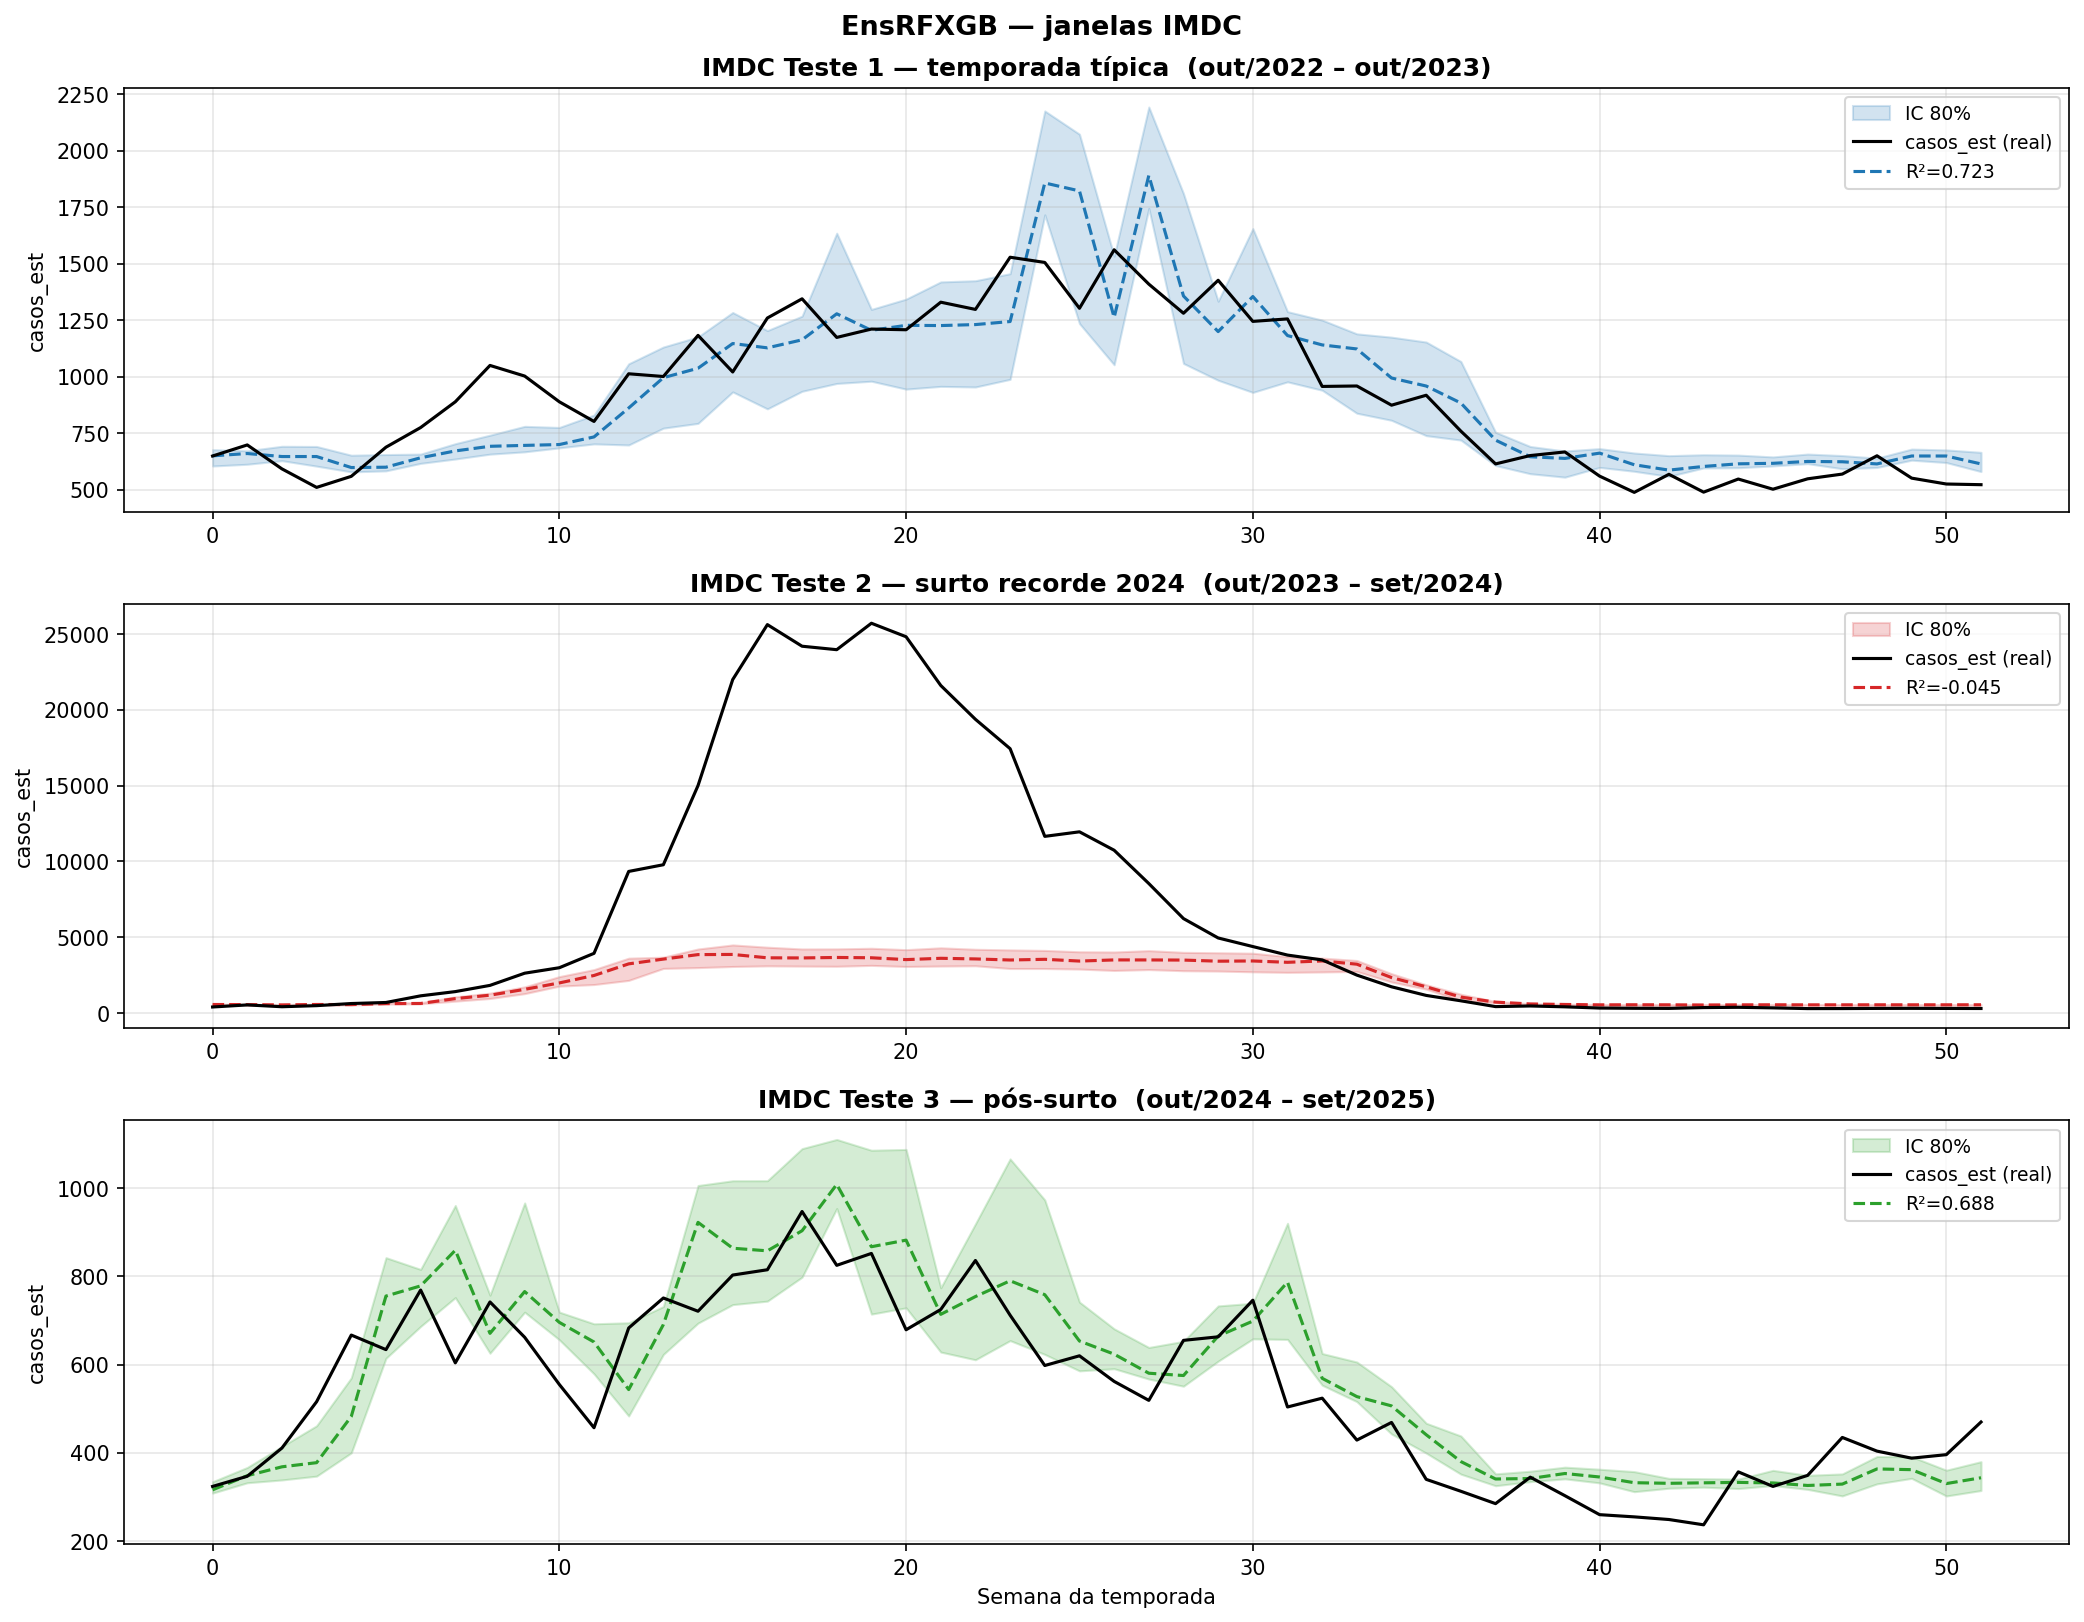

In [3]:
for nome in ['RF','XGBoost','LSTM','SARIMA','EnsRFXGB']:
    display(Image(os.path.join(FIG, f'{nome}_pred_vs_obs.png')))